# 💳 Home Credit Default Risk - Exploratory Data Analysis (EDA)

## 📌 Mục Tiêu Phân Tích
Notebook này thực hiện Phân Tích Khám Phá Dữ Liệu (**Exploratory Data Analysis - EDA**) trên bộ dữ liệu **Home Credit Default Risk** (từ Kaggle Competition):
1. **Hiểu rõ cấu trúc dữ liệu đa bảng**: `application_train.csv`, `bureau.csv`, `previous_application.csv`.
2. **Phân tích biến mục tiêu (`TARGET`)**: Đánh giá mức độ mất cân bằng lớp giữa khách hàng hoàn trả đầy đủ (0) và khách hàng vỡ nợ (1).
3. **Khám phá các đặc trưng tài chính & nhân khẩu học**: Số tiền vay (`AMT_CREDIT`), Thu nhập (`AMT_INCOME_TOTAL`), Tuổi tác, Thời gian làm việc, Điểm tín dụng bên thứ 3 (`EXT_SOURCE_1/2/3`).
4. **Đề xuất chiến lược Feature Engineering & Mô hình hóa** cho bài toán Credit Scoring.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data/raw/home-credit-default-risk')
if not DATA_DIR.exists():
    DATA_DIR = Path('data/raw/home-credit-default-risk')

print('✓ Đã nạp thành công thư viện & đường dẫn dữ liệu Home Credit.')

✓ Đã nạp thành công thư viện & đường dẫn dữ liệu Home Credit.


---
## 1. 📂 Nạp & Tổng Quan Dữ Liệu Bảng Chính (`application_train.csv`)

In [2]:
app_train = pd.read_csv(DATA_DIR / 'application_train.csv')
print(f'✓ Tổng số bản ghi (rows): {len(app_train):,}')
print(f'✓ Tổng số thuộc tính (features): {app_train.shape[1]}')
app_train.head(5)

✓ Tổng số bản ghi (rows): 307,511
✓ Tổng số thuộc tính (features): 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

---
## 2. 🎯 Phân Tích Biến Mục Tiêu (`TARGET` - Default Status)
- `TARGET = 0`: Khách hàng hoàn trả khoản vay đúng hạn.
- `TARGET = 1`: Khách hàng gặp khó khăn tài chính / Vỡ nợ.

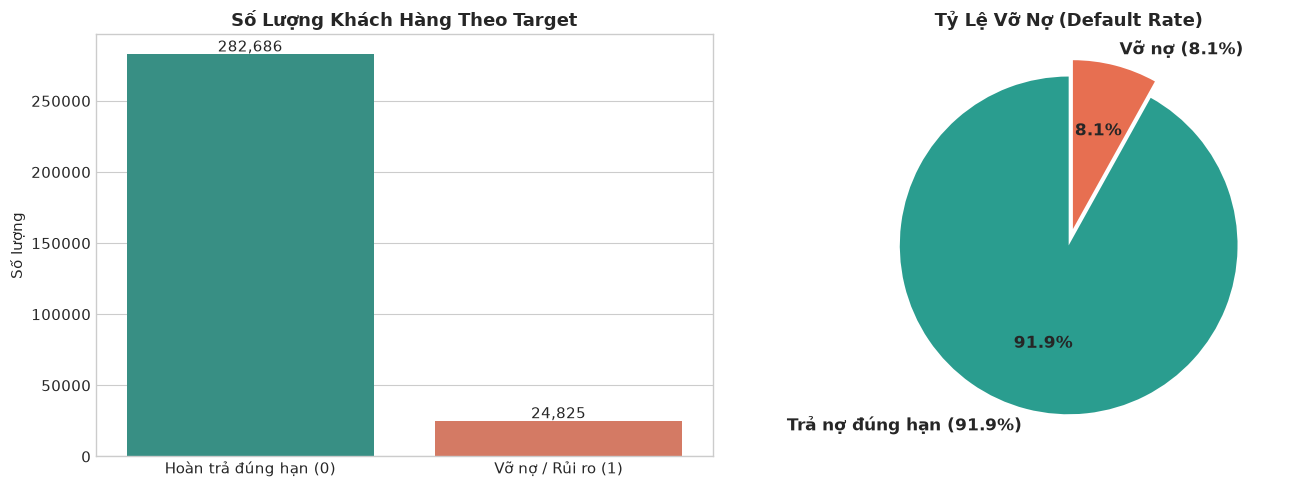

► Tỷ lệ vỡ nợ chung: 8.07% (24,825 / 307,511 khách hàng)


In [3]:
target_counts = app_train['TARGET'].value_counts()
target_rates = app_train['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Hoàn trả đúng hạn (0)', 'Vỡ nợ / Rủi ro (1)']
sns.barplot(x=labels, y=target_counts.values, ax=axes[0], palette=['#2a9d8f', '#e76f51'], hue=labels, legend=False)
axes[0].set_title('Số Lượng Khách Hàng Theo Target', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

axes[1].pie(target_rates, labels=[f'Trả nợ đúng hạn ({target_rates[0]:.1f}%)', f'Vỡ nợ ({target_rates[1]:.1f}%)'],
            autopct='%1.1f%%', startangle=90, colors=['#2a9d8f', '#e76f51'], explode=(0, 0.1),
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Tỷ Lệ Vỡ Nợ (Default Rate)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'► Tỷ lệ vỡ nợ chung: {target_rates[1]:.2f}% ({target_counts[1]:,} / {len(app_train):,} khách hàng)')

---
## 3. 🔍 Phân Tích Giá Trị Thiếu (Missing Values)

Số lượng thuộc tính bị thiếu dữ liệu: 67 / 122


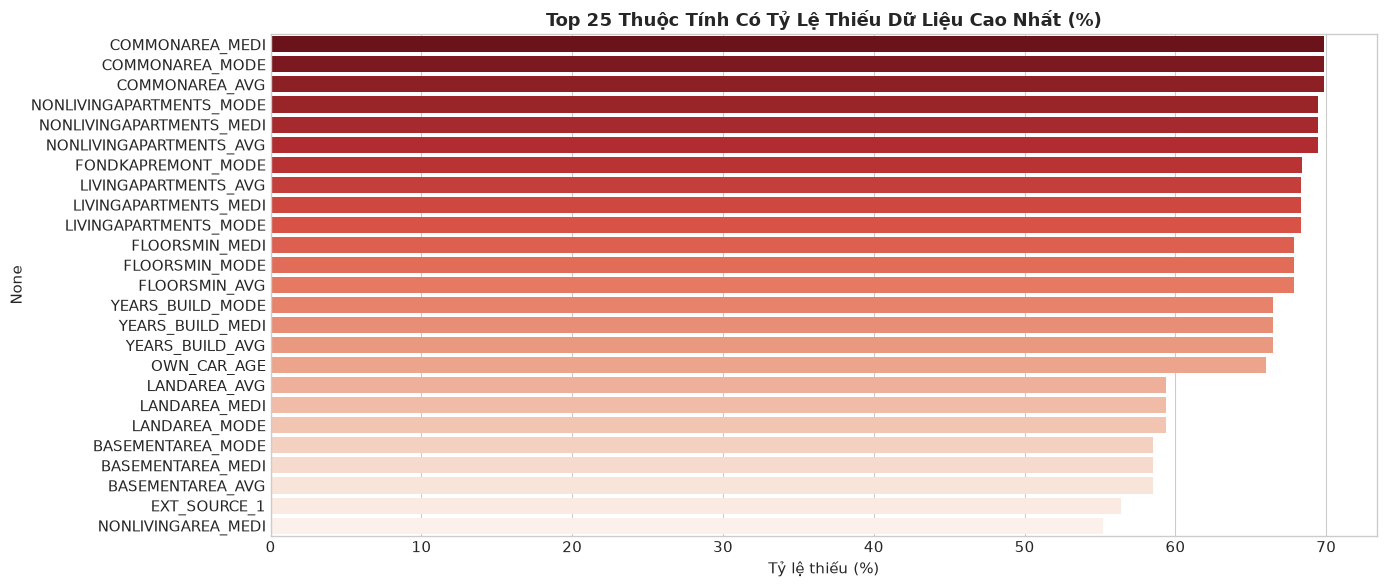

In [4]:
missing = app_train.isnull().sum()
missing_percent = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Ratio (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Ratio (%)', ascending=False)

print(f'Số lượng thuộc tính bị thiếu dữ liệu: {len(missing_df)} / {app_train.shape[1]}')
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_df.head(25)['Missing Ratio (%)'], y=missing_df.head(25).index, palette='Reds_r', hue=missing_df.head(25).index, legend=False)
plt.title('Top 25 Thuộc Tính Có Tỷ Lệ Thiếu Dữ Liệu Cao Nhất (%)', fontweight='bold')
plt.xlabel('Tỷ lệ thiếu (%)')
plt.tight_layout()
plt.show()

---
## 4. 💵 Phân Tích Đặc Trưng Tài Chính & Nhân Khẩu Học

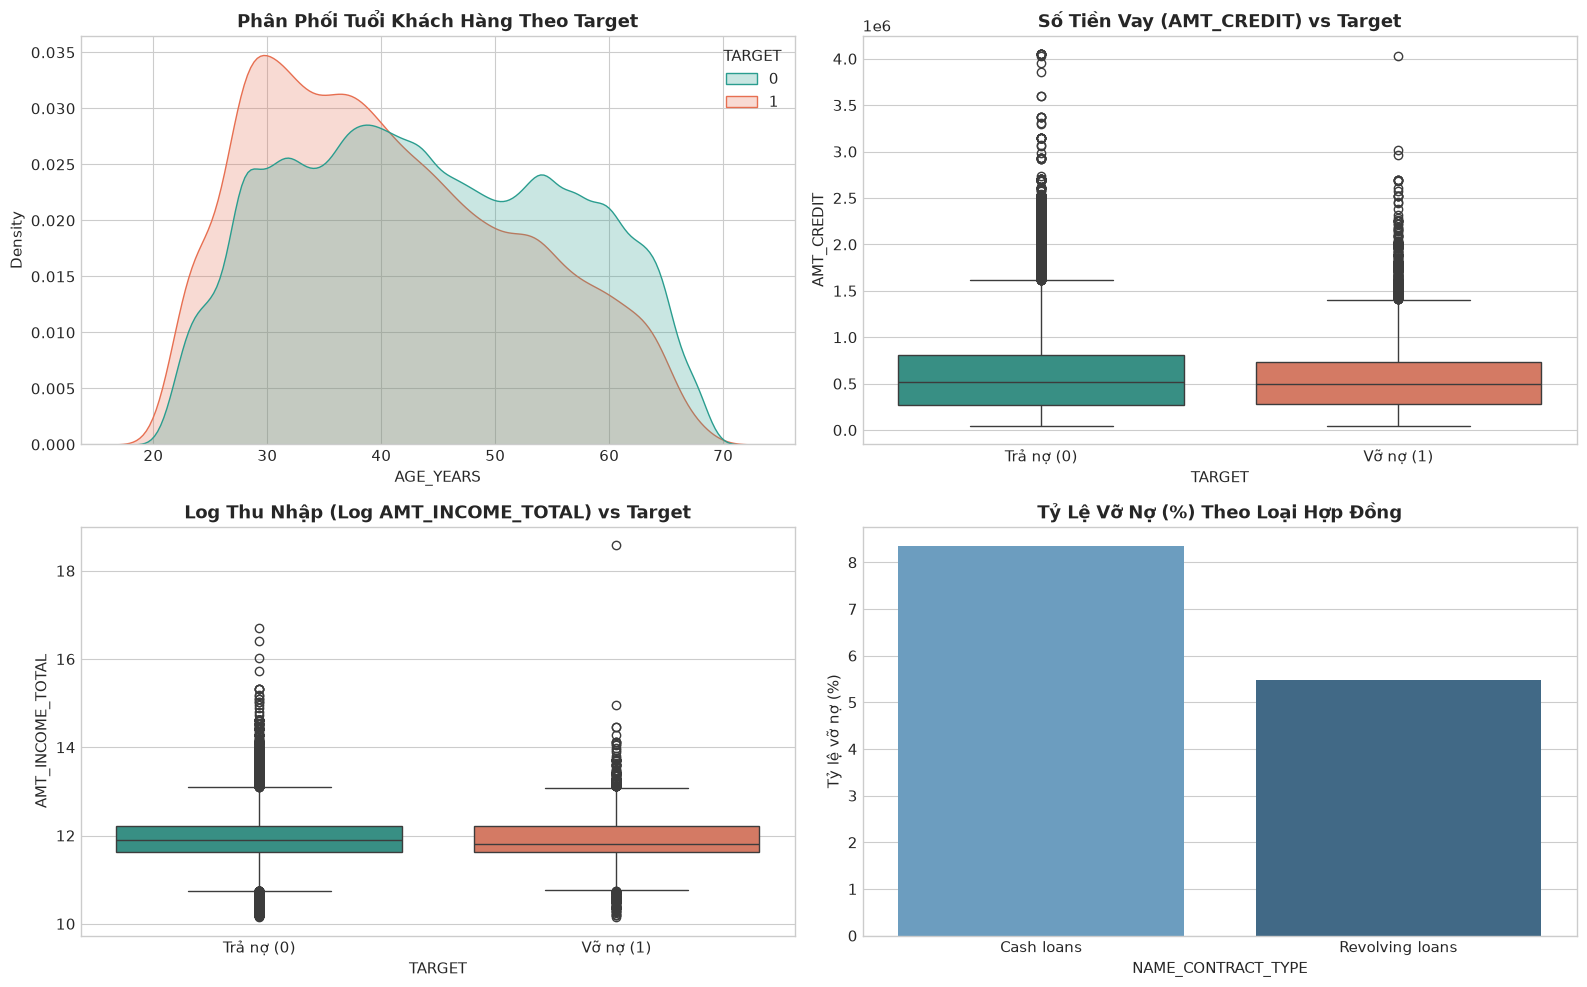

In [5]:
# Chuyển đổi tuổi từ DAYS_BIRTH
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Phân phối độ tuổi theo Target
sns.kdeplot(data=app_train, x='AGE_YEARS', hue='TARGET', common_norm=False, fill=True, ax=axes[0, 0], palette=['#2a9d8f', '#e76f51'])
axes[0, 0].set_title('Phân Phối Tuổi Khách Hàng Theo Target', fontweight='bold')

# Số tiền vay (AMT_CREDIT)
sns.boxplot(data=app_train, x='TARGET', y='AMT_CREDIT', ax=axes[0, 1], palette=['#2a9d8f', '#e76f51'], hue='TARGET', legend=False)
axes[0, 1].set_title('Số Tiền Vay (AMT_CREDIT) vs Target', fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Trả nợ (0)', 'Vỡ nợ (1)'])

# Thu nhập tổng (AMT_INCOME_TOTAL - dùng log scale)
sns.boxplot(data=app_train, x='TARGET', y=np.log1p(app_train['AMT_INCOME_TOTAL']), ax=axes[1, 0], palette=['#2a9d8f', '#e76f51'], hue='TARGET', legend=False)
axes[1, 0].set_title('Log Thu Nhập (Log AMT_INCOME_TOTAL) vs Target', fontweight='bold')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Trả nợ (0)', 'Vỡ nợ (1)'])

# Loại hợp đồng khoản vay
contract_churn = app_train.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100
sns.barplot(x=contract_churn.index, y=contract_churn.values, ax=axes[1, 1], palette='Blues_d', hue=contract_churn.index, legend=False)
axes[1, 1].set_title('Tỷ Lệ Vỡ Nợ (%) Theo Loại Hợp Đồng', fontweight='bold')
axes[1, 1].set_ylabel('Tỷ lệ vỡ nợ (%)')

plt.tight_layout()
plt.show()

---
## 5. 🌟 Phân Tích Điểm Tín Dụng Bên Thứ Bảy (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`)

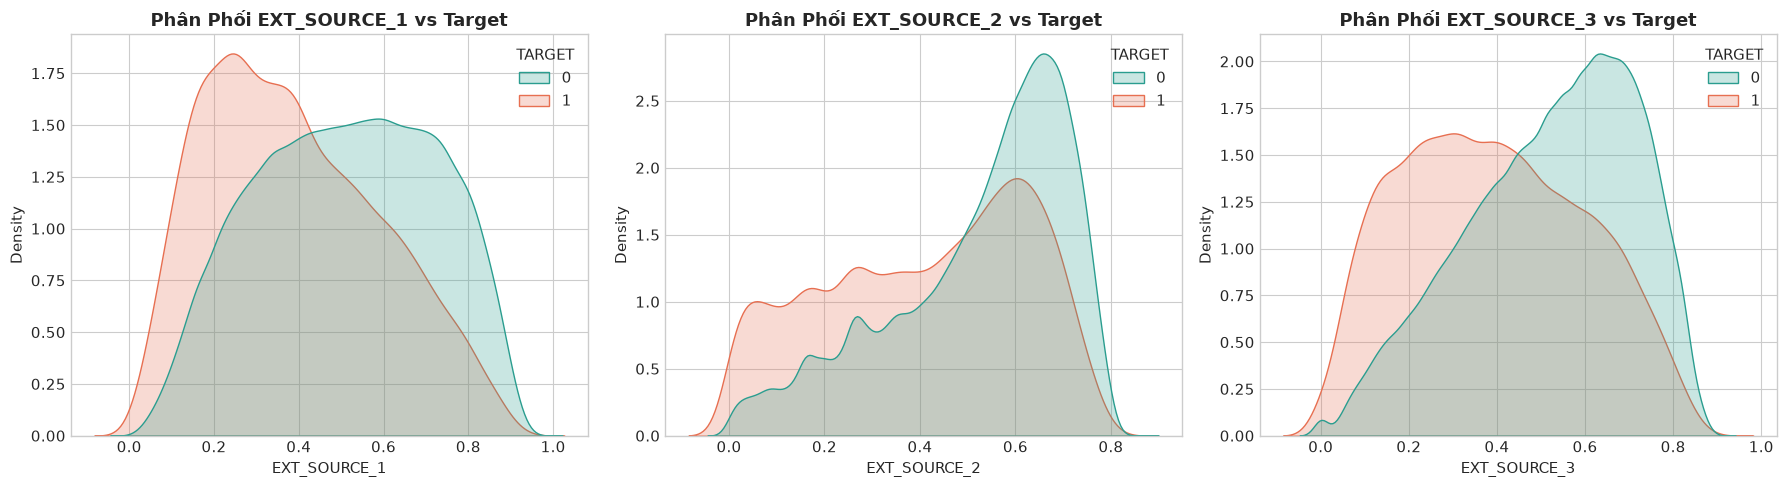

Hệ số tương quan với TARGET:
EXT_SOURCE_3   -0.18
EXT_SOURCE_2   -0.16
EXT_SOURCE_1   -0.16
TARGET          1.00
Name: TARGET, dtype: float64


In [6]:
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']
ext_data = app_train[ext_sources].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=app_train, x=col, hue='TARGET', common_norm=False, fill=True, ax=axes[i], palette=['#2a9d8f', '#e76f51'])
    axes[i].set_title(f'Phân Phối {col} vs Target', fontweight='bold')

plt.tight_layout()
plt.show()

# Hệ số tương quan với Target
corrs = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].corr()['TARGET'].sort_values()
print('Hệ số tương quan với TARGET:')
print(corrs)

---
## 6. 📊 Phân Tích Các Bảng Phụ (`bureau.csv` & `previous_application.csv`)

In [7]:
# Đọc mẫu dữ liệu bureau.csv
bureau = pd.read_csv(DATA_DIR / 'bureau.csv')
print(f'✓ bureau.csv: {len(bureau):,} bản ghi lịch sử tín dụng tại các tổ chức khác.')
bureau_agg = bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().reset_index().rename(columns={'SK_ID_BUREAU': 'BUREAU_LOAN_COUNT'})

# Đọc mẫu dữ liệu previous_application.csv
prev_app = pd.read_csv(DATA_DIR / 'previous_application.csv')
print(f'✓ previous_application.csv: {len(prev_app):,} đơn vay cũ tại Home Credit.')
prev_status = prev_app.groupby('NAME_CONTRACT_STATUS')['SK_ID_PREV'].count()
print('Trạng thái đơn vay quá khứ tại Home Credit:')
print(prev_status)

✓ bureau.csv: 1,716,428 bản ghi lịch sử tín dụng tại các tổ chức khác.
✓ previous_application.csv: 1,670,214 đơn vay cũ tại Home Credit.
Trạng thái đơn vay quá khứ tại Home Credit:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: SK_ID_PREV, dtype: int64


---
## 7. 🎯 Kết Luận & Định Hướng Xây Dựng Mô Hình Credit Scoring

### 📌 Insights Chính:
1. **Mất cân bằng dữ liệu**: Tỷ lệ vỡ nợ là **8.07%**. Cần áp dụng Class Weighting, SMOTE hoặc đánh giá bằng chỉ số **ROC-AUC**, **PR-AUC**, **KS Statistic**.
2. **Biến quan trọng hàng đầu**: Các điểm tín dụng bên ngoài (`EXT_SOURCE_1/2/3`) có tương quan âm rõ rệt với xác suất vỡ nợ.
3. **Tài chính & Thu nhập**: Tỷ lệ số tiền vay trên thu nhập (`CREDIT_TO_INCOME_RATIO`) và số tiền trả hàng tháng trên thu nhập (`ANNUITY_TO_INCOME_RATIO`) là các biến phái sinh cực kỳ tiềm năng.

### 💡 Chiến Lược Tiếp Theo:
- **Gom nhóm & Tổng hợp (Aggregation)** dữ liệu từ `bureau.csv` và `previous_application.csv` theo `SK_ID_CURR`.
- **Huấn luyện Mô hình Baseline**: Logistic Regression -> Random Forest -> LightGBM / XGBoost.
- **Giải thích Mô hình**: Sử dụng SHAP values để giải thích lý do từ chối/chấp thuận tín dụng.